In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd /content/drive/MyDrive/project_Weather/

[Errno 2] No such file or directory: '/content/drive/MyDrive/project_Weather/'
/content


In [ ]:
import os

os.listdir('/content/drive/MyDrive/')

['Getting started.pdf',
 'sets.pdf',
 'malayalam_unit01.pdf',
 'Hsslive-XI-chem-2. Atomic Structure.pdf',
 'Hsslive-XI-Cheem-Ch-6_Thermodynamics.pdf',
 'Classroom',
 'Chapter 1..pdf',
 'CHAPTER 3.pdf',
 'CHAPTER 2.pdf',
 'bsc-bca-1-sem-computer-fundamentals-and-digital-principles-21102407-oct-2021.pdf',
 'main_project 39.pdf',
 'main_project 39-pages-1 (1).pdf',
 'main_project 39-pages-1.pdf',
 'IMG_20250517_225637 (1).jpg',
 'IMG_20250517_225637.jpg',
 'Colab Notebooks',
 'Fake_News',
 'malaria_project',
 'project_skin',
 'project_Weather ']

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

path = '/content/drive/MyDrive/weather_project/'

os.makedirs(path, exist_ok=True)

print("Folder ready:", path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder ready: /content/drive/MyDrive/weather_project/


In [ ]:
cd /content/drive/MyDrive/weather_project/

/content/drive/MyDrive/weather_project


In [ ]:
ls

Weather.zip


In [ ]:
!unzip Weather.zip

Streaming output truncated to the last 5000 lines.
  inflating: dataset/frost/3913.jpg  
  inflating: dataset/frost/3914.jpg  
  inflating: dataset/frost/3915.jpg  
  inflating: dataset/frost/3916.jpg  
  inflating: dataset/frost/3917.jpg  
  inflating: dataset/frost/3918.jpg  
  inflating: dataset/frost/3919.jpg  
  inflating: dataset/frost/3920.jpg  
  inflating: dataset/frost/3921.jpg  
  inflating: dataset/frost/3922.jpg  
  inflating: dataset/frost/3923.jpg  
  inflating: dataset/frost/3924.jpg  
  inflating: dataset/frost/3925.jpg  
  inflating: dataset/frost/3926.jpg  
  inflating: dataset/frost/3927.jpg  
  inflating: dataset/frost/3928.jpg  
  inflating: dataset/frost/3929.jpg  
  inflating: dataset/frost/3930.jpg  
  inflating: dataset/frost/3931.jpg  
  inflating: dataset/frost/3932.jpg  
  inflating: dataset/frost/3933.jpg  
  inflating: dataset/frost/3934.jpg  
  inflating: dataset/frost/3935.jpg  
  inflating: dataset/frost/3936.jpg  
  inflating: dataset/frost/3937.jpg  

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [ ]:
dataset_path = "/content/drive/MyDrive/weather_project/dataset"

In [ ]:
dataset = datasets.ImageFolder(
    dataset_path,
    transform=transform
)

print("Classes:", dataset.classes)

Classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


In [ ]:
from torch.utils.data import DataLoader, random_split

In [ ]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [ ]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


In [ ]:
for param in model.parameters():
    param.requires_grad = False

In [ ]:
num_classes = len(dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 10

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", running_loss/len(train_loader))

Epoch: 1 Loss: 1.1079950791805289
Epoch: 2 Loss: 0.5866031686580458
Epoch: 3 Loss: 0.49505933426147286
Epoch: 4 Loss: 0.44479417090499124
Epoch: 5 Loss: 0.4131142046562461
Epoch: 6 Loss: 0.38977503360703936
Epoch: 7 Loss: 0.3776589594781399
Epoch: 8 Loss: 0.35099288158465264
Epoch: 9 Loss: 0.3425728470780129
Epoch: 10 Loss: 0.3242927258617656


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", 100 * correct / total)

Validation Accuracy: 85.57902403495994


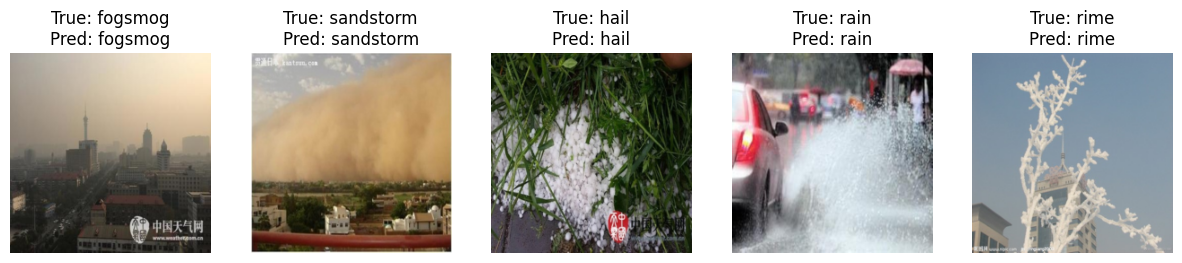

In [ ]:
 import random
import matplotlib.pyplot as plt
import torch

# number of images to display
num_images = 5

plt.figure(figsize=(15,5))

model.eval()

for i in range(num_images):

    # select random image
    index = random.randint(0, len(dataset)-1)

    img, label = dataset[index]

    img_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        _, pred = torch.max(outputs, 1)

    predicted_class = dataset.classes[pred.item()]
    true_class = dataset.classes[label]

    # convert tensor to displayable image
    img_display = img.permute(1,2,0).cpu()

    plt.subplot(1, num_images, i+1)
    plt.imshow(img_display)
    plt.title(f"True: {true_class}\nPred: {predicted_class}")
    plt.axis("off")

plt.show()

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/weather_project/model.pth")